In [11]:
import numpy as np
import os
import pandas as pd
import pickle
import matplotlib.pyplot as plt

In [12]:
with open('routerbench/routerbench_raw.pkl', 'rb') as file:
    data_raw = pickle.load(file)

with open('routerbench/routerbench_0shot.pkl', 'rb') as file:
    data0 = pickle.load(file)

with open('routerbench/routerbench_5shot.pkl', 'rb') as file:
    data5 = pickle.load(file)

with open('routerbench/data/embedding_cache_all-MiniLM-L12-v2.pkl', 'rb') as file:
    embed_all = pickle.load(file)

# with open('routerbench/data/routerbench/input_wide__04-11-04__routerbench.pkl', 'rb') as file:
#     embed_wide = pickle.load(file)


/tmp/ipykernel_15970/34427408.py:2: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data_raw = pickle.load(file)
/tmp/ipykernel_15970/34427408.py:5: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, 

In [13]:
embeddings = [i['embedding'] for i in embed_all]
np.array(embeddings).shape

(36511, 384)

In [14]:
to_exclude = []

for c in pd.unique(data5['eval_name']):
    if c.startswith("mmlu"):
        continue
    elif c.startswith('mtbench'):
        continue
    elif c.startswith('mbpp'):
        continue
    elif c.startswith('hellaswag'):
        continue
    elif c.startswith('winogrande'):
        continue
    elif c.startswith('arc-challenge'):
        continue
    elif c.startswith('grade-school-math'):
        continue
    else:
        to_exclude.append(c)

to_exclude


['Chinese_character_riddles',
 'abstract2title',
 'accounting_audit',
 'bias_detection',
 'chinese-lantern-riddles',
 'chinese-remainder-theorem',
 'chinese_ancient_masterpieces_dynasty',
 'chinese_ancient_poetry',
 'chinese_chu_ci',
 'chinese_famous_novel',
 'chinese_hard_translations',
 'chinese_homonym',
 'chinese_idioms',
 'chinese_modern_poem_identification',
 'chinese_poem',
 'chinese_shi_jing',
 'chinese_song_ci',
 'chinese_tang_poetries',
 'chinese_zodiac',
 'consensus_summary',
 'test-match']

In [15]:
llms = ['WizardLM/WizardLM-13B-V1.2', 'claude-instant-v1', 'claude-v1', 'claude-v2', 'gpt-3.5-turbo-1106',
       'gpt-4-1106-preview', 'meta/code-llama-instruct-34b-chat',
       'meta/llama-2-70b-chat', 'mistralai/mistral-7b-chat',
       'mistralai/mixtral-8x7b-chat', 'zero-one-ai/Yi-34B-Chat']

llms_short = ['WizardLM 13B', 'Claude Instant v1', 'Claude v1', 'Claude v2', 'GPT-3.5',
       'GPT-4', 'Code Llama 34b',
       'Llama 70b', 'Mistral 7b',
       'Mixtral 8x7b', 'Yi 34B']

In [16]:
from sklearn.model_selection import train_test_split


def get_nan_row_indices(arr):
    """
    Returns the indices of rows containing NaN values in a NumPy array.

    Args:
        arr (np.ndarray): The input NumPy array.

    Returns:
        np.ndarray: An array of row indices containing NaN values.
    """
    nan_mask = np.isnan(arr)
    row_has_nan = np.any(nan_mask, axis=1)
    return np.where(row_has_nan)[0]


filter_categories = 1

if filter_categories:
    mask_to_keep = ~data5['eval_name'].isin(to_exclude)
    data5 = data5[mask_to_keep].reset_index()

    embeddings_array = np.array(embeddings)
    embeddings = embeddings_array[mask_to_keep].tolist()

y_cost = np.zeros((len(embeddings), 11))
y_acc = np.zeros((len(embeddings), 11))

llm_acc_cost = ['WizardLM/WizardLM-13B-V1.2',
       'claude-instant-v1', 'claude-v1', 'claude-v2', 'gpt-3.5-turbo-1106',
       'gpt-4-1106-preview', 'meta/code-llama-instruct-34b-chat',
       'meta/llama-2-70b-chat', 'mistralai/mistral-7b-chat',
       'mistralai/mixtral-8x7b-chat', 'zero-one-ai/Yi-34B-Chat',
       'WizardLM/WizardLM-13B-V1.2|total_cost', 'claude-instant-v1|total_cost',
       'claude-v1|total_cost', 'claude-v2|total_cost',
       'gpt-3.5-turbo-1106|total_cost',
       'gpt-4-1106-preview|total_cost', 'meta/code-llama-instruct-34b-chat|total_cost', 'meta/llama-2-70b-chat|total_cost',
       'mistralai/mistral-7b-chat|total_cost', 'mistralai/mixtral-8x7b-chat|total_cost',
       'zero-one-ai/Yi-34B-Chat|total_cost']

for i in range(len(embeddings)):
    for j in range(11):
        y_cost[i, j] = data5[llm_acc_cost[j+11]][i]
        y_acc[i, j] = data5[llm_acc_cost[j]][i]

eval_data = data5['eval_name']

indices_to_delete = get_nan_row_indices(y_acc)
embeddings_clean = np.delete(embeddings, indices_to_delete, axis=0)
y_cost_clean = np.delete(y_cost, indices_to_delete, axis=0)
y_acc_clean = np.delete(y_acc, indices_to_delete, axis=0)
eval_data_clean = eval_data.drop(eval_data.index[indices_to_delete]).reset_index(drop=True)


x_train, x_test, y_acc_train, y_acc_test, y_cost_train, y_cost_test, eval_train, eval_test = train_test_split(embeddings_clean, y_acc_clean, y_cost_clean, eval_data_clean, stratify=eval_data_clean, test_size = 0.2, random_state=42)


Training NICKernel Multi-Output model...
✓ NICKernel Multi-Output Done!

Training XGBoost Multi-Output model...
✓ XGBoost Multi-Output Done!



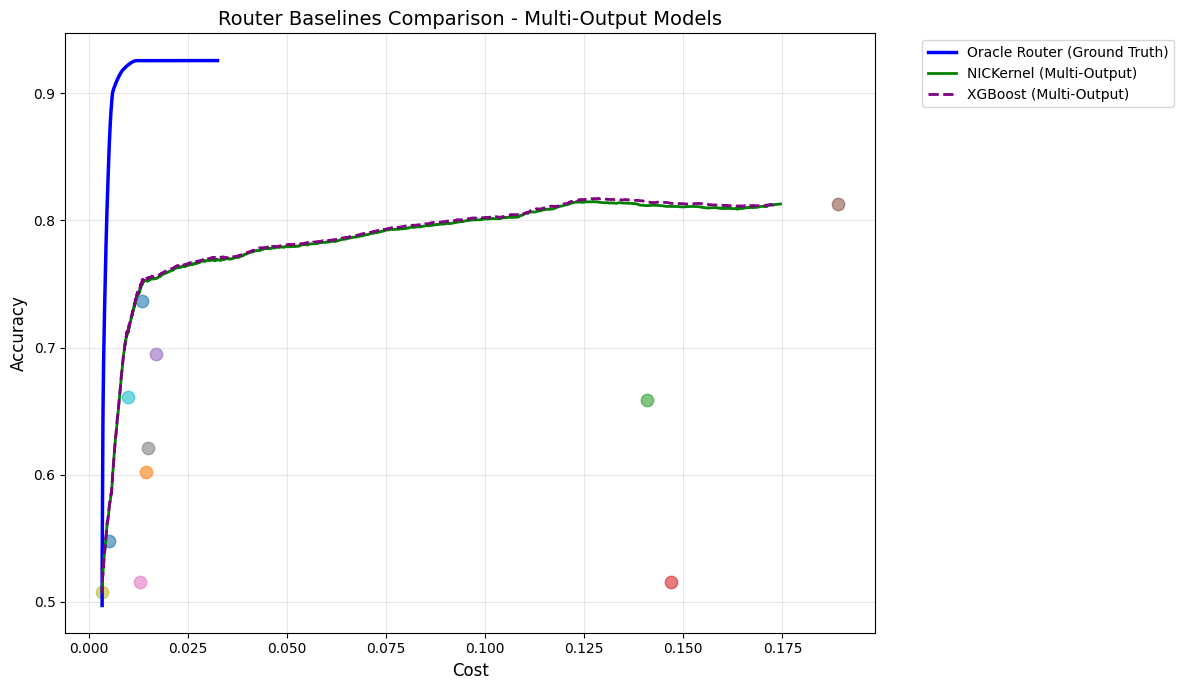


MULTI-OUTPUT BASELINE COMPARISON RESULTS
Oracle:                      Mean Acc: 0.9181, Mean Cost: 0.0104
NICKernel (Multi-Output):    Mean Acc: 0.7619, Mean Cost: 0.0524
XGBoost (Multi-Output):      Mean Acc: 0.7637, Mean Cost: 0.0528

XGBoost vs NICKernel:     +0.25% accuracy difference

Best Performing Model:  XGBoost with 0.7637 mean accuracy
Worst Performing Model: NICKernel with 0.7619 mean accuracy
Performance Gap: 0.0019


In [17]:
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from skactiveml.regressor import NICKernelRegressor

def score_auc(y_acc_test, y_cost_test, y_acc_pred, y_cost_pred, lam):
    n = y_acc_test.shape[0]
    y_cost_pred_ = y_cost_pred / np.max(y_cost_pred)
    y_cost_test_ = y_cost_test/np.max(y_cost_test)
    model_idx = ((1 - lam) * y_acc_pred - lam * y_cost_pred_).argmax(axis = 1)
    final_acc = np.zeros(n)
    final_cost = np.zeros(n)
    final_acc = y_acc_test[np.arange(n), model_idx]
    final_cost = y_cost_test_[np.arange(n), model_idx]
    return np.mean(final_acc), np.mean(final_cost)

lambdas = np.arange(0, 1.001, 0.0001)

# Oracle baseline
acc_oracle = np.zeros(len(lambdas))
cost_oracle = np.zeros(len(lambdas))
y_acc_pred_oracle = y_acc_test
y_cost_pred_oracle = y_cost_test

for i, lam in enumerate(lambdas):
    acc_oracle[i], cost_oracle[i] = score_auc(
      y_acc_test, y_cost_test, y_acc_pred_oracle, y_cost_pred_oracle, lam
    )

# NICKernelRegressor - Multi-Output
print("Training NICKernel Multi-Output model...")
nick_multi = MultiOutputRegressor(NICKernelRegressor(metric_dict={'gamma': 15.0}))
nick_multi.fit(x_train, y_acc_train)
y_acc_pred_nick_multi = nick_multi.predict(x_test)

acc_nick_multi = np.zeros(len(lambdas))
cost_nick_multi = np.zeros(len(lambdas))

for i, lam in enumerate(lambdas):
    acc_nick_multi[i], cost_nick_multi[i] = score_auc(
      y_acc_test, y_cost_test, y_acc_pred_nick_multi, y_cost_test, lam
    )
print("✓ NICKernel Multi-Output Done!\n")

# XGBoost - Multi-Output
print("Training XGBoost Multi-Output model...")
xgb_reg = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1e-3,
    reg_lambda=1.0,
    gamma=0.0,
    max_bin=256,
    random_state=42,
)

xgb_multi = MultiOutputRegressor(xgb_reg)
xgb_multi.fit(x_train, y_acc_train)
y_acc_pred_xgb = xgb_multi.predict(x_test)

acc_xgb = np.zeros(len(lambdas))
cost_xgb = np.zeros(len(lambdas))

for i, lam in enumerate(lambdas):
    acc_xgb[i], cost_xgb[i] = score_auc(
      y_acc_test, y_cost_test, y_acc_pred_xgb, y_cost_test, lam
    )
print("✓ XGBoost Multi-Output Done!\n")

# Random Forest - Multi-Output
# print("Training Random Forest Multi-Output model...")
# rf_reg = RandomForestRegressor(
#     n_estimators=500,
#     max_depth=12,
#     min_samples_split=5,
#     min_samples_leaf=2,
#     max_features='sqrt',
#     bootstrap=True,
#     n_jobs=-1,
#     random_state=42
# )

# rf_multi = MultiOutputRegressor(rf_reg)
# rf_multi.fit(x_train, y_acc_train)
# y_acc_pred_rf = rf_multi.predict(x_test)

# acc_rf = np.zeros(len(lambdas))
# cost_rf = np.zeros(len(lambdas))

# for i, lam in enumerate(lambdas):
#     acc_rf[i], cost_rf[i] = score_auc(
#       y_acc_test, y_cost_test, y_acc_pred_rf, y_cost_test, lam
#     )
# print("✓ Random Forest Multi-Output Done!\n")

# Plotting
plt.figure(figsize=(12, 7))

plt.plot(cost_oracle, acc_oracle, 'b-', linewidth=2.5, label='Oracle Router (Ground Truth)')
plt.plot(cost_nick_multi, acc_nick_multi, 'green', linestyle='-', linewidth=2,
      label='NICKernel (Multi-Output)')
plt.plot(cost_xgb, acc_xgb, 'purple', linestyle='--', linewidth=2,
      label='XGBoost (Multi-Output)')
# plt.plot(cost_rf, acc_rf, 'orange', linestyle='-.', linewidth=2,
#       label='Random Forest (Multi-Output)')

# Plot individual LLM points
for i, llm in enumerate(llms_short):
    avg_acc = np.mean(y_acc_test[:, i])
    avg_cost = np.mean(y_cost_test[:, i]) / np.max(y_cost_test)
    plt.scatter(avg_cost, avg_acc, s=80, alpha=0.6)

plt.xlabel('Cost', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Router Baselines Comparison - Multi-Output Models', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print comparison statistics
print("\n" + "="*60)
print("MULTI-OUTPUT BASELINE COMPARISON RESULTS")
print("="*60)
print(f"Oracle:                      Mean Acc: {acc_oracle.mean():.4f}, Mean Cost: {cost_oracle.mean():.4f}")
print(f"NICKernel (Multi-Output):    Mean Acc: {acc_nick_multi.mean():.4f}, Mean Cost: {cost_nick_multi.mean():.4f}")
print(f"XGBoost (Multi-Output):      Mean Acc: {acc_xgb.mean():.4f}, Mean Cost: {cost_xgb.mean():.4f}")
# print(f"Random Forest (Multi-Output): Mean Acc: {acc_rf.mean():.4f}, Mean Cost: {cost_rf.mean():.4f}")
print("="*60)

# Calculate improvements relative to NICKernel as baseline
xgb_vs_nick = ((acc_xgb.mean() - acc_nick_multi.mean()) / acc_nick_multi.mean()) * 100
# rf_vs_nick = ((acc_rf.mean() - acc_nick_multi.mean()) / acc_nick_multi.mean()) * 100
# rf_vs_xgb = ((acc_rf.mean() - acc_xgb.mean()) / acc_xgb.mean()) * 100

print(f"\nXGBoost vs NICKernel:     {xgb_vs_nick:+.2f}% accuracy difference")
# print(f"Random Forest vs NICKernel: {rf_vs_nick:+.2f}% accuracy difference")
# print(f"Random Forest vs XGBoost:   {rf_vs_xgb:+.2f}% accuracy difference")

# Find best performer
best_models = {
  'NICKernel': acc_nick_multi.mean(),
  'XGBoost': acc_xgb.mean(),
  # 'Random Forest': acc_rf.mean()
}
best_model = max(best_models, key=best_models.get)
worst_model = min(best_models, key=best_models.get)

print(f"\nBest Performing Model:  {best_model} with {best_models[best_model]:.4f} mean accuracy")
print(f"Worst Performing Model: {worst_model} with {best_models[worst_model]:.4f} mean accuracy")
print(f"Performance Gap: {(best_models[best_model] - best_models[worst_model]):.4f}")

In [ ]:
from skactiveml.regressor import SklearnRegressor
from xgboost import XGBRegressor

def DDQBC_active_learning_and_save_regressors_indices(
    x_train, y_train, y_cost_train, y_pred_baseline_train, directory,
    initial_batch_size=50, batch_size=50, save_interval=1,
    random_state=42, n_committee=10, n_iterations=150,
    llms=None, yi_name='zero-one-ai/Yi-34B-Chat',
    tau=1.0, epsilon=0.0,
    lambdas_acq=None,
):
    os.makedirs(directory, exist_ok=True)

    yi_idx = llms.index(yi_name)
    y_true = y_train[:, yi_idx].astype(float)
    y_labeled = np.full_like(y_true, np.nan, dtype=float)

    np.random.seed(random_state)
    initial_indices = np.random.choice(len(y_true), initial_batch_size, replace=False)
    y_labeled[initial_indices] = y_true[initial_indices]

    selection_order = list(initial_indices.tolist())

    # Committee creation
    committee = []
    for i in range(n_committee):
        xgb_model = XGBRegressor(
            objective="reg:squarederror",
            tree_method="hist",
            n_estimators=400,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=random_state + i,
        )
        committee.append(SklearnRegressor(xgb_model, missing_label=np.nan))

    def retrain_committee(iter_no: int):
        labeled_indices = np.where(~np.isnan(y_labeled))[0]
        for i, model in enumerate(committee):
            rng = np.random.RandomState(random_state + i + iter_no * 1000)
            boot = rng.choice(labeled_indices, len(labeled_indices), replace=True)
            model.fit(x_train[boot], y_labeled[boot])

    def save_checkpoint(n_labeled, iter_no):
        path = f"{directory}/Yi_34B_{n_labeled}.pkl"
        with open(path, "wb") as f:
            pickle.dump(committee, f)

    if lambdas_acq is None:
        lambdas_acq = np.arange(0, 1.001, 0.0001)

    y_cost_train_norm = y_cost_train / np.max(y_cost_train)

    # Fixed baseline arrays with Yi column removed
    old_indices = [j for j in range(y_pred_baseline_train.shape[1]) if j != yi_idx]
    baseline_preds_no_yi = y_pred_baseline_train[:, old_indices]
    cost_norm_no_yi = y_cost_train_norm[:, old_indices]
    yi_cost_norm = y_cost_train_norm[:, yi_idx]

    # Initial train + save
    retrain_committee(iter_no=0)
    save_checkpoint(n_labeled=initial_batch_size, iter_no=0)

    # Main loop
    for it in range(n_iterations):
        remaining_unlabeled = np.sum(np.isnan(y_labeled))
        if remaining_unlabeled == 0:
            break

        actual_batch_size = min(batch_size, int(remaining_unlabeled))

        committee_preds = np.stack([m.predict(x_train) for m in committee], axis=1)  # (n_train, K)

        # Unlabeled samples
        unlabeled_indices = np.where(np.isnan(y_labeled))[0]
        n_unlabeled = len(unlabeled_indices)

        comm_preds_u = committee_preds[unlabeled_indices]
        baseline_u = baseline_preds_no_yi[unlabeled_indices]
        cost_u_old = cost_norm_no_yi[unlabeled_indices]
        yi_cost_u = yi_cost_norm[unlabeled_indices]

        # Accumulate scores across lambdas
        dd_scores = np.zeros(n_unlabeled, dtype=np.float64)

        for lam in lambdas_acq:
            lam_f = float(lam)

            # Best existing competitor utility
            existing_utilities = (1 - lam_f) * baseline_u - lam_f * cost_u_old
            best_existing = existing_utilities.max(axis=1)

            # Committee utility estimates for Yi
            yi_utilities = (1 - lam_f) * comm_preds_u - lam_f * yi_cost_u[:, np.newaxis]

            # Binary votes and vote fraction
            p = (yi_utilities >= best_existing[:, np.newaxis]).astype(float).mean(axis=1)

            # Decision entropy
            eps_log = 1e-12
            H = -p * np.log(p + eps_log) - (1 - p) * np.log(1 - p + eps_log)
            H[(p < eps_log) | (p > 1 - eps_log)] = 0.0

            # Utility margin
            yi_mean_utility = yi_utilities.mean(axis=1)  # (n_u,)
            delta = yi_mean_utility - best_existing

            # Capped margin weight
            g = np.minimum(np.abs(delta), tau)

            # Score for this lambda
            score_lam = H * g

            # Pruning
            if epsilon > 0:
                max_yi = yi_utilities.max(axis=1)
                score_lam[max_yi < best_existing - epsilon] = 0.0

            dd_scores += score_lam

        dd_scores /= len(lambdas_acq)

        # Select top batch_size
        top_local = np.argsort(dd_scores)[::-1][:actual_batch_size]
        query_idx = unlabeled_indices[top_local]

        y_labeled[query_idx] = y_true[query_idx]
        selection_order.extend(query_idx.tolist())

        retrain_committee(iter_no=it + 1)

        if (it + 1) % save_interval == 0:
            n_labeled = initial_batch_size + ((it + 1) * batch_size)
            save_checkpoint(n_labeled=n_labeled, iter_no=it + 1)
            print(f"Iteration {it+1}: {n_labeled} samples saved")

In [ ]:
y_pred_baseline_train = xgb_multi.predict(x_train)
y_acc_pred_xgb_baseline_test = xgb_multi.predict(x_test)

DDQBC_active_learning_and_save_regressors_indices(
    x_train=x_train,
    y_train=y_acc_train,
    y_cost_train=y_cost_train,
    y_pred_baseline_train=y_pred_baseline_train,
    directory='ddqbc_XGB_checkpoints_yi',
    initial_batch_size=50,
    batch_size=50,
    save_interval=1,
    random_state=42,
    n_committee=10,
    n_iterations=300,
    llms=llms,
    yi_name='zero-one-ai/Yi-34B-Chat',
    tau=1.0,
    epsilon=0.0,
    lambdas_acq=None,
)

In [ ]:
from skactiveml.regressor import SklearnRegressor
from skactiveml.pool import QueryByCommittee
from xgboost import XGBRegressor

def WarmStart_DDQBC(
    x_train, y_train, y_cost_train, y_pred_baseline_train, directory,
    initial_batch_size=50, batch_size=50, save_interval=1,
    random_state=42, n_committee=10, n_iterations=200,
    llms=None, yi_name='zero-one-ai/Yi-34B-Chat',
    tau=1.0, epsilon=0.0,
    lambdas_acq=None,
    warmup_samples=500,
):
    os.makedirs(directory, exist_ok=True)

    yi_idx = llms.index(yi_name)
    y_true = y_train[:, yi_idx].astype(float)
    y_labeled = np.full_like(y_true, np.nan, dtype=float)

    np.random.seed(random_state)
    initial_indices = np.random.choice(len(y_true), initial_batch_size, replace=False)
    y_labeled[initial_indices] = y_true[initial_indices]

    # Committee creation
    committee = []
    for i in range(n_committee):
        xgb_model = XGBRegressor(
            objective="reg:squarederror",
            tree_method="hist",
            n_estimators=400,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=random_state + i,
        )
        committee.append(SklearnRegressor(xgb_model, missing_label=np.nan))

    def retrain_committee(iter_no: int):
        labeled_indices = np.where(~np.isnan(y_labeled))[0]
        for i, model in enumerate(committee):
            rng = np.random.RandomState(random_state + i + iter_no * 1000)
            boot = rng.choice(labeled_indices, len(labeled_indices), replace=True)
            model.fit(x_train[boot], y_labeled[boot])

    def save_checkpoint(n_labeled):
        path = f"{directory}/Yi_34B_{n_labeled}.pkl"
        with open(path, "wb") as f:
            pickle.dump(committee, f)

    if lambdas_acq is None:
        lambdas_acq = np.arange(0, 1.001, 0.0001)

    y_cost_train_norm = y_cost_train / np.max(y_cost_train)
    old_indices = [j for j in range(y_pred_baseline_train.shape[1]) if j != yi_idx]
    baseline_preds_no_yi = y_pred_baseline_train[:, old_indices]
    cost_norm_no_yi = y_cost_train_norm[:, old_indices]
    yi_cost_norm = y_cost_train_norm[:, yi_idx]

    # Figure out which iteration to switch from QBC -> DD-QBC
    warmup_iters = max(0, (warmup_samples - initial_batch_size) // batch_size)

    # Initial train + save
    retrain_committee(iter_no=0)
    save_checkpoint(n_labeled=initial_batch_size)

    qbc = QueryByCommittee(missing_label=np.nan)

    for it in range(n_iterations):
        remaining_unlabeled = np.sum(np.isnan(y_labeled))
        if remaining_unlabeled == 0:
            break

        actual_batch_size = min(batch_size, int(remaining_unlabeled))
        use_qbc = (it < warmup_iters)

        if use_qbc:
            query_idx = qbc.query(
                X=x_train,
                y=y_labeled,
                ensemble=committee,
                fit_ensemble=False,
                batch_size=actual_batch_size
            )
            query_idx = np.atleast_1d(query_idx).astype(int)
        else:
            committee_preds = np.stack([m.predict(x_train) for m in committee], axis=1)

            unlabeled_indices = np.where(np.isnan(y_labeled))[0]
            n_unlabeled = len(unlabeled_indices)

            comm_preds_u = committee_preds[unlabeled_indices]
            baseline_u = baseline_preds_no_yi[unlabeled_indices]
            cost_u_old = cost_norm_no_yi[unlabeled_indices]
            yi_cost_u = yi_cost_norm[unlabeled_indices]

            dd_scores = np.zeros(n_unlabeled, dtype=np.float64)

            for lam in lambdas_acq:
                lam_f = float(lam)

                existing_utilities = (1 - lam_f) * baseline_u - lam_f * cost_u_old
                best_existing = existing_utilities.max(axis=1)

                yi_utilities = (1 - lam_f) * comm_preds_u - lam_f * yi_cost_u[:, np.newaxis]

                p = (yi_utilities >= best_existing[:, np.newaxis]).astype(float).mean(axis=1)

                eps_log = 1e-12
                H = -p * np.log(p + eps_log) - (1 - p) * np.log(1 - p + eps_log)
                H[(p < eps_log) | (p > 1 - eps_log)] = 0.0

                yi_mean_utility = yi_utilities.mean(axis=1)
                delta = yi_mean_utility - best_existing
                g = np.minimum(np.abs(delta), tau)

                score_lam = H * g

                if epsilon > 0:
                    max_yi = yi_utilities.max(axis=1)
                    score_lam[max_yi < best_existing - epsilon] = 0.0

                dd_scores += score_lam

            dd_scores /= len(lambdas_acq)

            top_local = np.argsort(dd_scores)[::-1][:actual_batch_size]
            query_idx = unlabeled_indices[top_local]

        y_labeled[query_idx] = y_true[query_idx]
        retrain_committee(iter_no=it + 1)

        if (it + 1) % save_interval == 0:
            n_labeled = initial_batch_size + ((it + 1) * batch_size)
            phase = "QBC" if use_qbc else "DD-QBC"
            save_checkpoint(n_labeled=n_labeled)
            print(f"Iteration {it+1} [{phase}]: {n_labeled} samples saved")

In [ ]:
y_pred_baseline_train = xgb_multi.predict(x_train)

for warmup_size in [300, 350, 400, 450]:
    WarmStart_DDQBC(
        x_train=x_train,
        y_train=y_acc_train,
        y_cost_train=y_cost_train,
        y_pred_baseline_train=y_pred_baseline_train,
        directory=f'warmstart{warmup_size}_ddqbc_XGB_checkpoints_yi_42',
        initial_batch_size=50,
        batch_size=50,
        save_interval=1,
        random_state=42,
        n_committee=10,
        n_iterations=100,
        llms=llms,
        yi_name='zero-one-ai/Yi-34B-Chat',
        tau=1.0,
        epsilon=0.0,
        lambdas_acq=lambdas,
        warmup_samples=warmup_size,
    )

In [18]:
from sklearn.model_selection import train_test_split

y_pred_baseline_train = xgb_multi.predict(x_train)
y_pred_baseline_test = xgb_multi.predict(x_test)

x_mon, _, y_cost_mon, _, y_pred_baseline_mon, _ = train_test_split(
    x_test, y_cost_test, y_pred_baseline_test,
    train_size=2000, random_state=42,
)

In [19]:
from skactiveml.regressor import SklearnRegressor
from skactiveml.pool import QueryByCommittee
from xgboost import XGBRegressor
import math

def ExploreExploit_DDQBC(
    x_train, y_train, y_cost_train, y_pred_baseline_train, directory,
    initial_batch_size=50, batch_size=50, save_interval=1,
    random_state=42, n_committee=10, n_iterations=150,
    llms=None, yi_name='zero-one-ai/Yi-34B-Chat',
    tau=1.0, epsilon=0.0, lambdas_acq=None,
    # Exploration-exploitation
    P_0=1.0, P_min=0.05, gamma=2.0,
    # Stopping rule
    x_monitor=None, y_cost_monitor=None, y_pred_baseline_monitor=None,
    flip_threshold=0.005,
):
    os.makedirs(directory, exist_ok=True)

    yi_idx = llms.index(yi_name)
    y_true = y_train[:, yi_idx].astype(float)
    y_labeled = np.full_like(y_true, np.nan, dtype=float)

    np.random.seed(random_state)
    initial_indices = np.random.choice(len(y_true), initial_batch_size, replace=False)
    y_labeled[initial_indices] = y_true[initial_indices]

    # Committee creation
    committee = []
    for i in range(n_committee):
        xgb_model = XGBRegressor(
            objective="reg:squarederror",
            tree_method="hist",
            n_estimators=400,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=random_state + i,
        )
        committee.append(SklearnRegressor(xgb_model, missing_label=np.nan))

    def retrain_committee(iter_no: int):
        labeled_indices = np.where(~np.isnan(y_labeled))[0]
        for i, model in enumerate(committee):
            rng = np.random.RandomState(random_state + i + iter_no * 1000)
            boot = rng.choice(labeled_indices, len(labeled_indices), replace=True)
            model.fit(x_train[boot], y_labeled[boot])

    def save_checkpoint(n_labeled):
        path = f"{directory}/Yi_34B_{n_labeled}.pkl"
        with open(path, "wb") as f:
            pickle.dump(committee, f)

    if lambdas_acq is None:
        lambdas_acq = np.arange(0, 1.001, 0.0001)

    y_cost_train_norm = y_cost_train / np.max(y_cost_train)
    old_indices = [j for j in range(y_pred_baseline_train.shape[1]) if j != yi_idx]
    baseline_preds_no_yi = y_pred_baseline_train[:, old_indices]
    cost_norm_no_yi = y_cost_train_norm[:, old_indices]
    yi_cost_norm = y_cost_train_norm[:, yi_idx]

    #flip number set up
    use_stopping = (x_monitor is not None)
    if use_stopping:
        n_mon = len(x_monitor)
        y_cost_mon_norm = y_cost_monitor / np.max(y_cost_train)
        baseline_mon_no_yi = y_pred_baseline_monitor[:, old_indices]
        cost_mon_no_yi = y_cost_mon_norm[:, old_indices]
        yi_cost_mon = y_cost_mon_norm[:, yi_idx]

        prev_routing = None

    # Initial train + save
    retrain_committee(iter_no=0)
    save_checkpoint(n_labeled=initial_batch_size)

    qbc = QueryByCommittee(missing_label=np.nan)

    for it in range(n_iterations):
        remaining_unlabeled = np.sum(np.isnan(y_labeled))
        if remaining_unlabeled == 0:
            break

        actual_batch_size = min(batch_size, int(remaining_unlabeled))

        #compute probability
        P_r = P_min + (P_0 - P_min) / (1 + it) ** gamma
        B_explore = max(1, math.ceil(P_r * actual_batch_size))
        B_exploit = actual_batch_size - B_explore

        #QBC
        explore_idx = qbc.query(
            X=x_train,
            y=y_labeled,
            ensemble=committee,
            fit_ensemble=False,
            batch_size=B_explore,
        )
        explore_idx = np.atleast_1d(explore_idx).astype(int)

        #DDQBC
        if B_exploit > 0:
            committee_preds = np.stack([m.predict(x_train) for m in committee], axis=1)

            unlabeled_indices = np.where(np.isnan(y_labeled))[0]
            # Remove QBC selected samples from exploitation pool
            exploit_pool = np.setdiff1d(unlabeled_indices, explore_idx)
            n_pool = len(exploit_pool)

            if n_pool > 0:
                comm_preds_u = committee_preds[exploit_pool]
                baseline_u = baseline_preds_no_yi[exploit_pool]
                cost_u_old = cost_norm_no_yi[exploit_pool]
                yi_cost_u = yi_cost_norm[exploit_pool]

                dd_scores = np.zeros(n_pool, dtype=np.float64)

                for lam in lambdas_acq:
                    lam_f = float(lam)

                    existing_utilities = (1 - lam_f) * baseline_u - lam_f * cost_u_old
                    best_existing = existing_utilities.max(axis=1)

                    yi_utilities = (1 - lam_f) * comm_preds_u - lam_f * yi_cost_u[:, np.newaxis]

                    p = (yi_utilities >= best_existing[:, np.newaxis]).astype(float).mean(axis=1)

                    eps_log = 1e-12
                    H = -p * np.log(p + eps_log) - (1 - p) * np.log(1 - p + eps_log)
                    H[(p < eps_log) | (p > 1 - eps_log)] = 0.0

                    yi_mean_utility = yi_utilities.mean(axis=1)
                    delta = yi_mean_utility - best_existing
                    g = np.minimum(np.abs(delta), tau)

                    score_lam = H * g

                    if epsilon > 0:
                        max_yi = yi_utilities.max(axis=1)
                        score_lam[max_yi < best_existing - epsilon] = 0.0

                    dd_scores += score_lam

                dd_scores /= len(lambdas_acq)

                actual_exploit = min(B_exploit, n_pool)
                top_local = np.argsort(dd_scores)[::-1][:actual_exploit]
                exploit_idx = exploit_pool[top_local]
            else:
                exploit_idx = np.array([], dtype=int)
        else:
            exploit_idx = np.array([], dtype=int)

        query_idx = np.concatenate([explore_idx, exploit_idx]).astype(int)

        y_labeled[query_idx] = y_true[query_idx]
        retrain_committee(iter_no=it + 1)

        #flip number computation
        flip_rate = None
        if use_stopping:
            mon_preds = np.stack([m.predict(x_monitor) for m in committee], axis=1)
            yi_pred_mon = mon_preds.mean(axis=1)

            current_routing = np.empty((n_mon, len(lambdas_acq)), dtype=int)

            for li, lam in enumerate(lambdas_acq):
                lam_f = float(lam)
                util_old = (1 - lam_f) * baseline_mon_no_yi - lam_f * cost_mon_no_yi
                util_yi = (1 - lam_f) * yi_pred_mon - lam_f * yi_cost_mon
                full_util = np.column_stack([util_old, util_yi[:, np.newaxis]])
                current_routing[:, li] = full_util.argmax(axis=1)

            if prev_routing is not None:
                flip_rate = (current_routing != prev_routing).mean()

            prev_routing = current_routing.copy()

        if (it + 1) % save_interval == 0:
            n_labeled = initial_batch_size + ((it + 1) * batch_size)
            save_checkpoint(n_labeled=n_labeled)
            flip_str = f", flip_rate={flip_rate:.4f}" if flip_rate is not None else ""
            print(
                f"Iteration {it+1}: {n_labeled} samples saved "
                f"[P_r={P_r:.3f}, B_explore={len(explore_idx)}, "
                f"B_exploit={len(exploit_idx)}{flip_str}]"
            )
        #early stop check
        if use_stopping and flip_rate is not None and flip_rate < flip_threshold:
            n_labeled = int(np.sum(~np.isnan(y_labeled)))
            save_checkpoint(n_labeled=n_labeled)
            print(
                f"Early stopping at iteration {it+1}: flip_rate={flip_rate:.4f} "
                f"< {flip_threshold}. Final checkpoint: {n_labeled} samples."
            )
            break

In [ ]:
ExploreExploit_DDQBC(
    x_train=x_train, y_train=y_acc_train,
    y_cost_train=y_cost_train,
    y_pred_baseline_train=y_pred_baseline_train,
    directory='ee_dcqbc_XGB_checkpoints_yi_42',
    initial_batch_size=50, batch_size=50, save_interval=1,
    random_state=42, n_committee=10, n_iterations=150,
    llms=llms, yi_name='zero-one-ai/Yi-34B-Chat',
    tau=1.0, epsilon=0.0, lambdas_acq=lambdas,
    P_0=1.0, P_min=0.05, gamma=2.0,
    x_monitor=x_mon, y_cost_monitor=y_cost_mon,
    y_pred_baseline_monitor=y_pred_baseline_mon,
    flip_threshold=0.005,
)